# K-Means Clustering + PCA: Country Education & Health Profiles

**Research question:** Can countries be grouped into interpretable clusters using their combined education and health indicators?

**Approach:** Average each country across available years to get one profile per country, then cluster on all 12 features simultaneously. PCA reduces the 12-dimensional space to 2D for visualization.

| Group | Variables |
|-------|-----------|
| Education (5) | Bachelor's attainment, Compulsory education duration, Youth NEET, School life exp. (tertiary), Tertiary enrolment |
| Health (7) | Crude death rate, Fertility rate, DPT immunization, TB incidence, Health expenditure, Overweight prevalence, Hypertension prevalence |

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score
import warnings
warnings.filterwarnings('ignore')

In [2]:
df = pd.read_csv('Frida_Kahlo_Normalized_Clean.csv')

col_map = {
    'Country': 'country',
    'Region': 'region',
    # Education
    'Educational attainment, at least Bachelor\'s or equivalent, population 25+, total (%) (cumulative)': 'bachelors',
    'Compulsory education, duration (years)': 'compulsory_edu',
    'Share of youth not in education, employment or training, total (% of youth population)  (modeled ILO estimate)': 'neet',
    'School life expectancy, tertiary, both sexes (years)': 'school_life_tertiary',
    'Enrolment in tertiary education, all programmes, both sexes (number)': 'tertiary_enrolment',
    # Health
    'Death rate, crude (per 1,000 people)': 'death_rate',
    'Fertility rate, total (births per woman)': 'fertility_rate',
    'Immunization, DPT (% of children ages 12-23 months)': 'immunization_dpt',
    'Incidence of tuberculosis (per 100,000 people)': 'tb_incidence',
    'Current health expenditure per capita, PPP (current international $)': 'health_expenditure',
    'Prevalence of overweight (% of adults)': 'overweight',
    'Prevalence of hypertension (% of adults ages 30-79)': 'hypertension'
}

df = df.rename(columns=col_map)

features = [
    'bachelors', 'compulsory_edu', 'neet', 'school_life_tertiary', 'tertiary_enrolment',
    'death_rate', 'fertility_rate', 'immunization_dpt', 'tb_incidence',
    'health_expenditure', 'overweight', 'hypertension'
]

keep = ['country', 'region'] + features
df = df[keep].dropna(subset=features)

# Average across years to get one profile per country
country_df = (
    df.groupby('country')
    .agg({'region': 'first', **{f: 'mean' for f in features}})
    .reset_index()
    .dropna(subset=features)
)

print(f'Countries: {len(country_df)}')
print(f'Features:  {len(features)}')
country_df.head()

Countries: 112
Features:  12


,country,region,bachelors,compulsory_edu,neet,school_life_tertiary,tertiary_enrolment,death_rate,fertility_rate,immunization_dpt,tb_incidence,health_expenditure,overweight,hypertension
0,Afghanistan,"Middle East, North Africa, Afghanistan & Pakistan",0.041049,0.363636,0.781204,0.034107,0.007439,0.432054,0.858653,0.212766,0.177018,0.018926,0.350085,0.601449
1,Albania,Europe & Central Asia,0.316958,0.363636,0.510507,0.452512,0.004354,0.412846,0.108541,1.000000,0.014652,0.075469,0.719094,0.700181
2,Angola,Sub-Saharan Africa,0.042900,0.090909,0.528497,0.064335,0.006249,0.516897,0.859369,0.106383,0.400566,0.016207,0.235613,0.605072
3,Armenia,Europe & Central Asia,0.529111,0.636364,0.476952,0.364863,0.003021,0.530470,0.111609,0.886525,0.046615,0.117113,0.612326,0.892512
4,Australia,East Asia & Pacific,0.660142,0.545455,0.118180,0.837663,0.051701,0.365972,0.140586,0.898936,0.005210,0.495056,0.761595,0.248188


Best k by silhouette: 2  (score = 0.325)


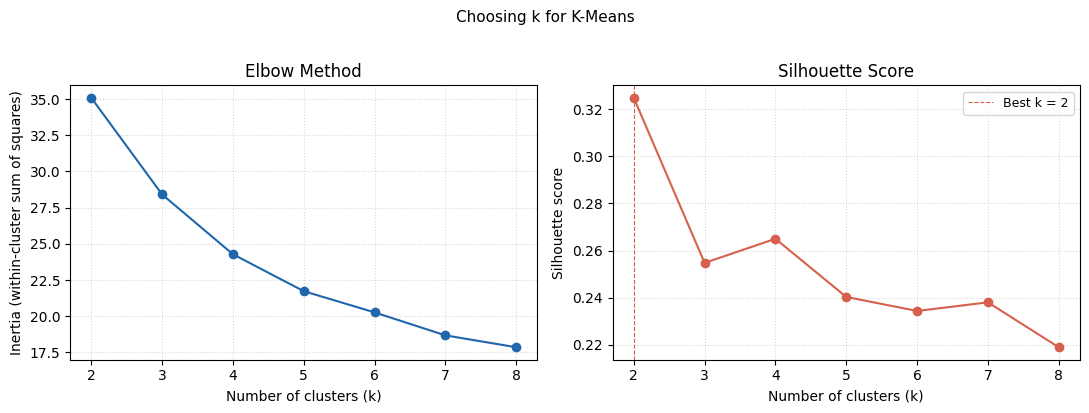

In [3]:
X = country_df[features].values

ks = range(2, 9)
inertias, silhouettes = [], []

for k in ks:
    km = KMeans(n_clusters=k, random_state=42, n_init=20)
    labels = km.fit_predict(X)
    inertias.append(km.inertia_)
    silhouettes.append(silhouette_score(X, labels))

best_k = ks[int(np.argmax(silhouettes))]
print(f'Best k by silhouette: {best_k}  (score = {max(silhouettes):.3f})')

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4))

ax1.plot(ks, inertias, marker='o', color='#2166ac')
ax1.set_xlabel('Number of clusters (k)')
ax1.set_ylabel('Inertia (within-cluster sum of squares)')
ax1.set_title('Elbow Method')
ax1.grid(linestyle=':', alpha=0.5)

ax2.plot(ks, silhouettes, marker='o', color='#d6604d')
ax2.axvline(best_k, color='#d6604d', linestyle='--', linewidth=0.8, label=f'Best k = {best_k}')
ax2.set_xlabel('Number of clusters (k)')
ax2.set_ylabel('Silhouette score')
ax2.set_title('Silhouette Score')
ax2.legend(fontsize=9)
ax2.grid(linestyle=':', alpha=0.5)

plt.suptitle('Choosing k for K-Means', fontsize=11, y=1.02)
plt.tight_layout()
plt.show()

In [4]:
K = 4  # Adjust based on elbow/silhouette above

km_final = KMeans(n_clusters=K, random_state=42, n_init=20)
country_df['cluster_id'] = km_final.fit_predict(X)
country_df['cluster'] = 'Cluster ' + (country_df['cluster_id'] + 1).astype(str)

print('Countries per cluster:')
print(country_df['cluster'].value_counts().sort_index())
print()
print('Sample countries per cluster:')
for cl in sorted(country_df['cluster'].unique()):
    sample = country_df[country_df['cluster'] == cl]['country'].sample(
        min(5, (country_df['cluster'] == cl).sum()), random_state=1).tolist()
    print(f'  {cl}: {", ".join(sample)}')

Countries per cluster:
cluster
Cluster 1    20
Cluster 2    32
Cluster 3    33
Cluster 4    27
Name: count, dtype: int64

Sample countries per cluster:
  Cluster 1: Croatia, Serbia, Georgia, Lithuania, Bulgaria
  Cluster 2: Tanzania, Benin, Philippines, Myanmar, Rwanda
  Cluster 3: Jordan, Mauritius, Belize, Thailand, Uzbekistan
  Cluster 4: New Zealand, Luxembourg, Norway, Canada, Sweden


In [5]:
pca = PCA(n_components=2, random_state=42)
coords = pca.fit_transform(X)

country_df['pc1'] = coords[:, 0]
country_df['pc2'] = coords[:, 1]

var1, var2 = pca.explained_variance_ratio_
print(f'PC1 explains {var1:.1%} of variance')
print(f'PC2 explains {var2:.1%} of variance')
print(f'Total: {var1 + var2:.1%}')
print()

# Top feature loadings for interpretability
loadings = pd.DataFrame(
    pca.components_.T,
    index=features,
    columns=['PC1', 'PC2']
).round(3)
print('PCA loadings (what each axis captures):')
display(loadings.sort_values('PC1', ascending=False))

PC1 explains 44.1% of variance
PC2 explains 14.8% of variance
Total: 58.9%

PCA loadings (what each axis captures):


,PC1,PC2
fertility_rate,0.433,-0.090
neet,0.269,0.250
tb_incidence,0.176,0.011
hypertension,0.071,0.775
death_rate,0.016,0.085
tertiary_enrolment,-0.013,-0.092
compulsory_edu,-0.249,0.167
immunization_dpt,-0.284,0.079
health_expenditure,-0.314,-0.276
school_life_tertiary,-0.385,-0.081


In [6]:
export_cols = ['country', 'region', 'cluster', 'pc1', 'pc2'] + features
export_df = country_df[export_cols].copy()
export_df.to_csv('cluster_data.csv', index=False)

print('Saved: cluster_data.csv')
print(f'Rows: {len(export_df)} (one per country)')
print(f'Columns: {list(export_cols)}')

Saved: cluster_data.csv
Rows: 112 (one per country)
Columns: ['country', 'region', 'cluster', 'pc1', 'pc2', 'bachelors', 'compulsory_edu', 'neet', 'school_life_tertiary', 'tertiary_enrolment', 'death_rate', 'fertility_rate', 'immunization_dpt', 'tb_incidence', 'health_expenditure', 'overweight', 'hypertension']


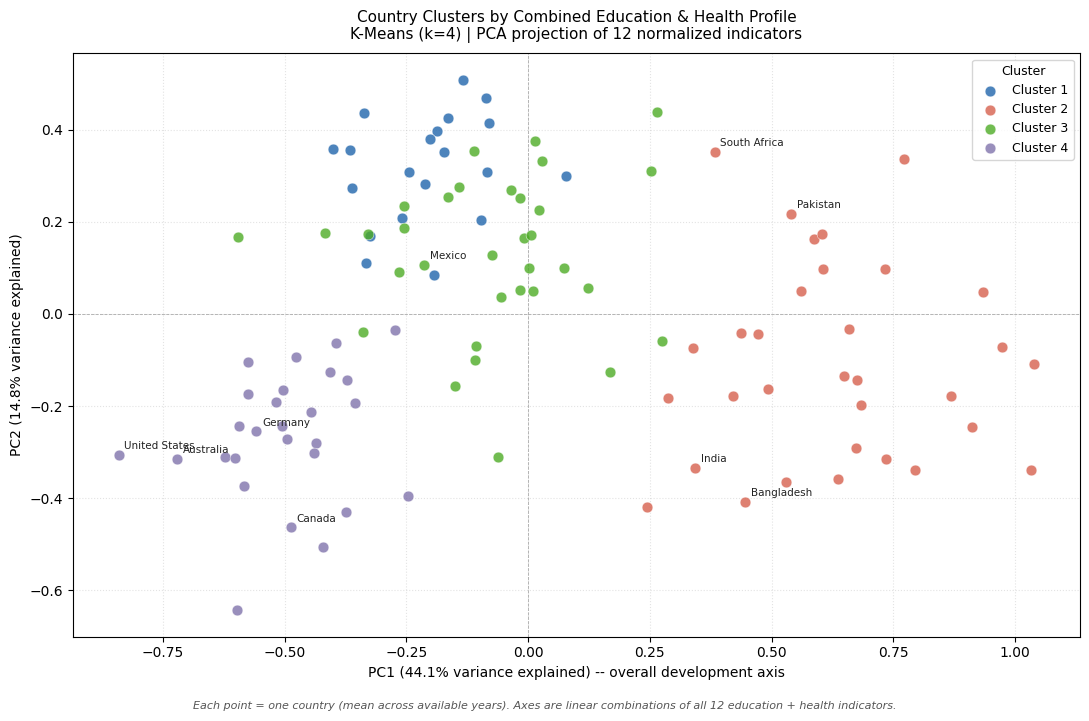

Saved: cluster_scatter.png


In [ ]:
PALETTE = ['#2166ac', '#d6604d', '#4dac26', '#8073ac']
cluster_labels = sorted(country_df['cluster'].unique())
color_map = {cl: PALETTE[i] for i, cl in enumerate(cluster_labels)}

# Countries to annotate -- spread across the PCA space
label_countries = [
    'United States', 'Germany', 'Japan', 'Australia', 'Canada',
    'Brazil', 'China', 'Mexico', 'Turkey', 'South Africa',
    'India', 'Nigeria', 'Pakistan', 'Bangladesh',
    'Ethiopia', 'Chad'
]

fig, ax = plt.subplots(figsize=(11, 7))

for cl in cluster_labels:
    grp = country_df[country_df['cluster'] == cl]
    ax.scatter(grp['pc1'], grp['pc2'],
               c=color_map[cl], s=60, alpha=0.8,
               edgecolors='white', linewidths=0.4,
               label=cl, zorder=3)

# Annotate notable countries
for _, row in country_df[country_df['country'].isin(label_countries)].iterrows():
    ax.annotate(
        row['country'],
        (row['pc1'], row['pc2']),
        fontsize=7.5, color='#222222',
        xytext=(4, 4), textcoords='offset points'
    )

ax.axhline(0, color='#aaaaaa', linewidth=0.6, linestyle='--', zorder=1)
ax.axvline(0, color='#aaaaaa', linewidth=0.6, linestyle='--', zorder=1)
ax.set_xlabel(f'PC1 ({var1:.1%} variance explained) -- overall development axis', fontsize=10)
ax.set_ylabel(f'PC2 ({var2:.1%} variance explained)', fontsize=10)
ax.set_title(
    'Country Clusters by Combined Education & Health Profile\n'
    'K-Means (k=4) | PCA projection of 12 normalized indicators',
    fontsize=11, pad=10
)
ax.legend(title='Cluster', fontsize=9, title_fontsize=9, loc='best')
ax.grid(linestyle=':', alpha=0.35, zorder=0)

fig.text(
    0.5, -0.02,
    'Each point = one country (mean across available years). '
    'Axes are linear combinations of all 12 education + health indicators.',
    ha='center', fontsize=8, color='#555555', style='italic'
)

plt.tight_layout()
plt.savefig('cluster_scatter.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: cluster_scatter.png')

Saved: cluster_profiles.csv


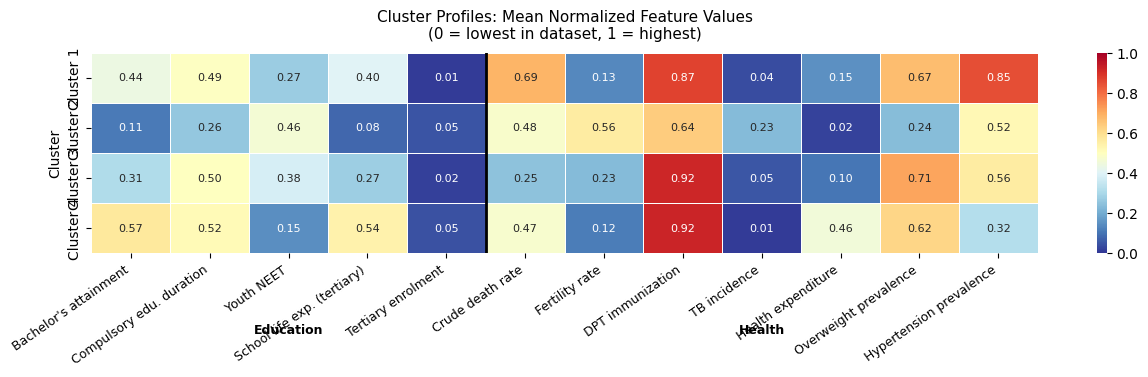

Saved: cluster_heatmap.png


In [ ]:
# Human-readable feature labels for the heatmap
feat_labels = {
    'bachelors':           "Bachelor's attainment",
    'compulsory_edu':      'Compulsory edu. duration',
    'neet':                'Youth NEET',
    'school_life_tertiary':'School life exp. (tertiary)',
    'tertiary_enrolment':  'Tertiary enrolment',
    'death_rate':          'Crude death rate',
    'fertility_rate':      'Fertility rate',
    'immunization_dpt':    'DPT immunization',
    'tb_incidence':        'TB incidence',
    'health_expenditure':  'Health expenditure',
    'overweight':          'Overweight prevalence',
    'hypertension':        'Hypertension prevalence'
}

# Mean feature values per cluster
profile = (
    country_df.groupby('cluster')[features]
    .mean()
    .rename(columns=feat_labels)
    .sort_index()
)

# Export for Tableau tooltips
profile.reset_index().to_csv('cluster_profiles.csv', index=False)
print('Saved: cluster_profiles.csv')

fig, ax = plt.subplots(figsize=(13, 4))
sns.heatmap(
    profile,
    ax=ax,
    annot=True, fmt='.2f',
    cmap='RdYlBu_r',
    center=0.5, vmin=0, vmax=1,
    linewidths=0.5, linecolor='white',
    annot_kws={'size': 8}
)

# Divider between education (cols 0-4) and health (cols 5-11)
ax.axvline(5, color='black', linewidth=2)
ax.text(2.5, -0.4, 'Education', ha='center', fontsize=9, fontweight='bold',
        transform=ax.get_xaxis_transform())
ax.text(8.5, -0.4, 'Health', ha='center', fontsize=9, fontweight='bold',
        transform=ax.get_xaxis_transform())

ax.set_xlabel('')
ax.set_ylabel('Cluster', fontsize=10)
ax.set_title(
    'Cluster Profiles: Mean Normalized Feature Values\n'
    '(0 = lowest in dataset, 1 = highest)',
    fontsize=11, pad=10
)
plt.xticks(rotation=35, ha='right', fontsize=9)
plt.tight_layout()
plt.savefig('cluster_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: cluster_heatmap.png')